<a href="https://colab.research.google.com/github/create-with-pritam/Drowsiness-Detection-using-YOLO-/blob/main/Drowsiness_detect_YOLO_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
from matplotlib import pyplot as plt
import  numpy as np
import cv2

**2.Load Model**

In [ ]:
model= torch.hub.load('ultralytics/yolov5','yolov5s')


/usr/local/lib/python3.11/dist-packages/torch/hub.py:330: UserWarning: You are about to download and run code from an untrusted repository. In a future release, this won't be allowed. To add the repository to your trusted list, change the command to {calling_fn}(..., trust_repo=False) and a command prompt will appear asking for an explicit confirmation of trust, or load(..., trust_repo=True), which will assume that the prompt is to be answered with 'yes'. You can also use load(..., trust_repo='check') which will only prompt for confirmation if the repo is not already trusted. This will eventually be the default behaviour
  warnings.warn(
Downloading: "https://github.com/ultralytics/yolov5/zipball/master" to /root/.cache/torch/hub/master.zip


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


YOLOv5 🚀 2025-6-27 Python-3.11.13 torch-2.6.0+cu124 CPU

100%|██████████| 14.1M/14.1M [00:00<00:00, 168MB/s]

Fusing layers... 
YOLOv5s summary: 213 layers, 7225885 parameters, 0 gradients, 16.4 GFLOPs
Adding AutoShape... 


In [ ]:
model

AutoShape(
  (model): DetectMultiBackend(
    (model): DetectionModel(
      (model): Sequential(
        (0): Conv(
          (conv): Conv2d(3, 32, kernel_size=(6, 6), stride=(2, 2), padding=(2, 2))
          (act): SiLU(inplace=True)
        )
        (1): Conv(
          (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
          (act): SiLU(inplace=True)
        )
        (2): C3(
          (cv1): Conv(
            (conv): Conv2d(64, 32, kernel_size=(1, 1), stride=(1, 1))
            (act): SiLU(inplace=True)
          )
          (cv2): Conv(
            (conv): Conv2d(64, 32, kernel_size=(1, 1), stride=(1, 1))
            (act): SiLU(inplace=True)
          )
          (cv3): Conv(
            (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1))
            (act): SiLU(inplace=True)
          )
          (m): Sequential(
            (0): Bottleneck(
              (cv1): Conv(
                (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1))
  

**3.Make Detections**

In [ ]:
img='https://dn60005mpuo2f.cloudfront.net/graphics/upo-pages/spring_street_after.jpg'

In [ ]:
results=model(img)
results.print()

/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
image 1/1: 1791x3072 25 persons, 1 bicycle, 3 cars, 1 bus, 1 traffic light, 3 benchs, 1 dog
Speed: 1162.1ms pre-process, 473.6ms inference, 34.5ms NMS per image at shape (1, 3, 384, 640)


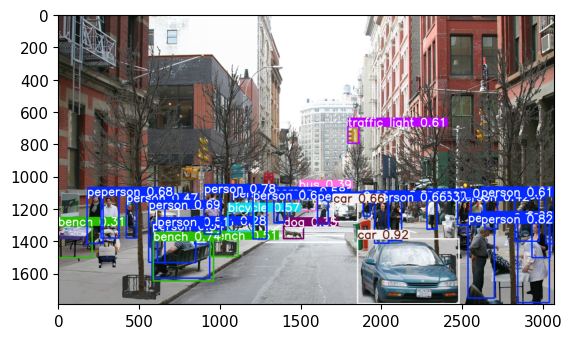

In [ ]:
%matplotlib inline
plt.imshow(np.squeeze(results.render()))
plt.show()

In [ ]:
results.xyxy

[tensor([[1.85516e+03, 1.38825e+03, 2.48354e+03, 1.78961e+03, 9.20787e-01, 2.00000e+00],
         [2.84716e+03, 1.29206e+03, 3.04308e+03, 1.78219e+03, 8.23381e-01, 0.00000e+00],
         [9.04820e+02, 1.10401e+03, 1.00503e+03, 1.35956e+03, 7.84636e-01, 0.00000e+00],
         [5.90874e+02, 1.39977e+03, 9.63317e+02, 1.64821e+03, 7.44478e-01, 1.30000e+01],
         [2.53935e+03, 1.28458e+03, 2.70211e+03, 1.75421e+03, 6.97761e-01, 0.00000e+00],
         [5.61584e+02, 1.20396e+03, 6.62130e+02, 1.53307e+03, 6.85197e-01, 0.00000e+00],
         [2.66031e+02, 1.12264e+03, 3.77493e+02, 1.38372e+03, 6.75533e-01, 0.00000e+00],
         [1.80406e+02, 1.12365e+03, 2.79111e+02, 1.41715e+03, 6.66298e-01, 0.00000e+00],
         [1.70538e+03, 1.16449e+03, 1.85633e+03, 1.28222e+03, 6.60774e-01, 2.00000e+00],
         [1.96025e+03, 1.15646e+03, 2.04902e+03, 1.41564e+03, 6.60601e-01, 0.00000e+00],
         [1.60763e+03, 1.15066e+03, 1.67394e+03, 1.29746e+03, 6.57402e-01, 0.00000e+00],
         [2.04447e+03

**4.Real time Deatections**

In [ ]:
from IPython.display import display, Javascript, Image

In [ ]:
from IPython.display import display, Javascript, Image
from base64 import b64decode, b64encode
#import cv2
#import numpy as np
import PIL
import io
#import torch

# Load your YOLOv5 model (can be custom too)
model = torch.hub.load('ultralytics/yolov5', 'yolov5s')  # Replace with your fine-tuned model if needed

# Converts JavaScript base64 image to OpenCV BGR image
def js_to_image(js_reply):
    image_bytes = b64decode(js_reply.split(',')[1])
    jpg_as_np = np.frombuffer(image_bytes, dtype=np.uint8)
    img = cv2.imdecode(jpg_as_np, flags=1)
    return img

# Converts OpenCV image to base64 PNG for display
def image_to_bytes(image):
    _, buffer = cv2.imencode('.png', image)
    encoded = b64encode(buffer).decode('utf-8')
    return f'data:image/png;base64,{encoded}'

# JS to capture photo
def take_photo(filename='photo.jpg', quality=0.8):
    js = Javascript('''
      async function takePhoto(quality) {
        const div = document.createElement('div');
        const capture = document.createElement('button');
        capture.textContent = 'Capture';
        div.appendChild(capture);

        const video = document.createElement('video');
        video.style.display = 'block';
        const stream = await navigator.mediaDevices.getUserMedia({video: true});

        document.body.appendChild(div);
        div.appendChild(video);
        video.srcObject = stream;
        await video.play();

        google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

        await new Promise((resolve) => capture.onclick = resolve);

        const canvas = document.createElement('canvas');
        canvas.width = video.videoWidth;
        canvas.height = video.videoHeight;
        canvas.getContext('2d').drawImage(video, 0, 0);
        stream.getVideoTracks()[0].stop();
        div.remove();
        return canvas.toDataURL('image/jpeg', quality);
      }
    ''')
    display(js)
    from google.colab import output
    data = output.eval_js('takePhoto({})'.format(quality))
    img = js_to_image(data)
    cv2.imwrite(filename, img)
    return img, filename



Using cache found in /root/.cache/torch/hub/ultralytics_yolov5_master
YOLOv5 🚀 2025-6-27 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)

Fusing layers... 
YOLOv5s summary: 213 layers, 7225885 parameters, 0 gradients, 16.4 GFLOPs
Adding AutoShape... 


<IPython.core.display.Javascript object>

Image saved to yolo_photo.jpg


/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


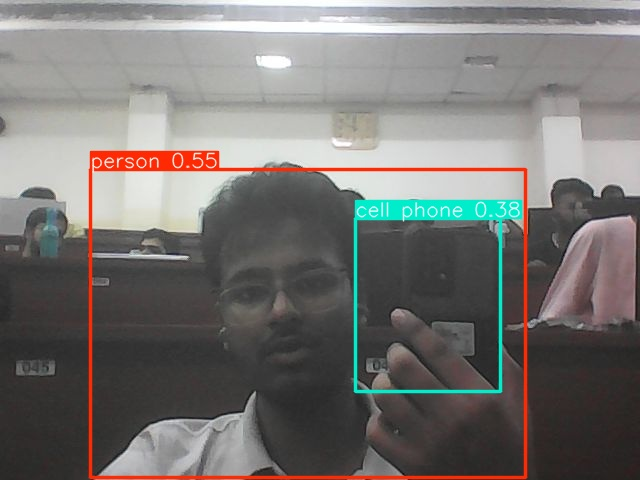

In [ ]:
# 📷 Capture photo and run YOLOv5 detection
try:
    img, filename = take_photo('yolo_photo.jpg')
    print(f"Image saved to {filename}")

    # Run detection using YOLOv5
    results = model(img)

    # Draw results on image
    img_with_boxes = np.squeeze(results.render())  # Render detection boxes

    # Save and show image
    cv2.imwrite('yolo_result.jpg', img_with_boxes)
    display(Image('yolo_result.jpg'))

except Exception as e:
    print("Error:", e)

In [ ]:
from IPython.display import display, HTML, Javascript, clear_output
import ipywidgets as widgets
from google.colab import output
import time

# 1. First run this cell to set up the cleanup function
def setup_cleanup():
    output.register_callback('notebook.cleanup', lambda: globals().update({'processing_active': False}))
    display(HTML("""
    <script>
    function forceCleanup() {
        google.colab.kernel.invokeFunction('notebook.cleanup', [], {});
        console.log("Cleanup signal sent");
    }
    </script>
    """))

setup_cleanup()

# 2. Then run this cell for the video detection
processing_active = True  # Global control variable

def video_detection():
    display(HTML("""
    <div id="video-container">
        <video id="video" width="640" height="480" autoplay></video>
        <div>
            <button onclick="startDetection()">Start</button>
            <button onclick="stopDetection()">Stop</button>
            <button onclick="forceCleanup(); stopDetection()">Force Stop</button>
        </div>
        <div id="status">Status: Ready</div>
    </div>

    <script>
    let video = document.getElementById('video');
    let statusDiv = document.getElementById('status');
    let stream = null;
    let interval = null;

    // Start webcam
    async function startWebcam() {
        try {
            stream = await navigator.mediaDevices.getUserMedia({ video: true });
            video.srcObject = stream;
            statusDiv.textContent = 'Status: Webcam active';
        } catch (err) {
            statusDiv.textContent = 'Error: ' + err.name;
        }
    }

    // Start detection
    function startDetection() {
        if (!stream) startWebcam();
        interval = setInterval(() => {
            const canvas = document.createElement('canvas');
            canvas.width = video.videoWidth;
            canvas.height = video.videoHeight;
            canvas.getContext('2d').drawImage(video, 0, 0);
            const imgData = canvas.toDataURL('image/jpeg', 0.8);
            google.colab.kernel.invokeFunction('notebook.process_frame', [imgData], {});
        }, 100);
        statusDiv.textContent = 'Status: Detection running';
    }

    // Stop detection
    function stopDetection() {
        if (interval) clearInterval(interval);
        if (stream) {
            stream.getTracks().forEach(track => track.stop());
            stream = null;
        }
        statusDiv.textContent = 'Status: Stopped';
    }
    </script>
    """))

    # Create stop button that works from Python side
    stop_button = widgets.Button(description="Python Stop Button")
    def on_stop_button(b):
        global processing_active
        processing_active = False
        display(Javascript("stopDetection()"))
        print("Processing stopped from Python")
    stop_button.on_click(on_stop_button)
    display(stop_button)

    # Frame processing loop
    while processing_active:
        time.sleep(0.1)
    print("Video processing completely stopped")

# 3. Run this to start the detection
video_detection()

from IPython.display import display, Javascript, HTML, Image, clear_output
from base64 import b64decode, b64encode
import cv2
import numpy as np
import torch
import time
import ipywidgets as widgets

# Load YOLOv5 model
model = torch.hub.load('ultralytics/yolov5', 'yolov5s')
model.eval()
# Convert OpenCV image to base64 for display
def image_to_base64(image):
    _, buffer = cv2.imencode('.jpg', image)
    return b64encode(buffer).decode('utf-8')

# JavaScript code to create webcam video stream
video_js = """
<video id="video" width="640" height="480" autoplay></video>
<button id="start">Start Detection</button>
<button id="stop">Stop Detection</button>
<script>
var video = document.getElementById('video');
var startBtn = document.getElementById('start');
var stopBtn = document.getElementById('stop');
var stream;
var interval;

// Start video stream
navigator.mediaDevices.getUserMedia({ video: true })
  .then(function(s) {
    stream = s;
    video.srcObject = stream;
  });

// Start detection
startBtn.onclick = function() {
  interval = setInterval(function() {
    var canvas = document.createElement('canvas');
    canvas.width = video.videoWidth;
    canvas.height = video.videoHeight;
    canvas.getContext('2d').drawImage(video, 0, 0);
    var imgData = canvas.toDataURL('image/jpeg', 0.8);
    google.colab.kernel.invokeFunction('notebook.process_frame', [imgData], {});
  }, 100);
};

// Stop detection
stopBtn.onclick = function() {
  clearInterval(interval);
  if (stream) {
    stream.getTracks().forEach(function(track) {
      track.stop();
    });
  }
};
</script>
"""

# Global variable to store the latest frame
latest_frame = None

def process_frame(img_data):
    global latest_frame
    # Convert JS image data to OpenCV format
    image_bytes = b64decode(img_data.split(',')[1])
    nparr = np.frombuffer(image_bytes, np.uint8)
    frame = cv2.imdecode(nparr, cv2.IMREAD_COLOR)

    # Run YOLOv5 detection
    results = model(frame)

    # Render detections
    frame_with_detections = np.squeeze(results.render())

    # Convert back to base64 for display
    img_str = image_to_base64(frame_with_detections)

    # Update the latest frame
    latest_frame = img_str

# Register the Python function with Colab
from google.colab import output
output.register_callback('notebook.process_frame', process_frame)

# Display the video player
display(HTML(video_js))

# Display loop for showing processed frames
stop_button = widgets.Button(description="Stop Video")
display(stop_button)

image_widget = widgets.Image(format='jpg')
display(image_widget)

def stop_video(b):
    clear_output()
    print("Video processing stopped.")

stop_button.on_click(stop_video)

# Update the displayed image
try:
    while True:
        if latest_frame is not None:
            image_widget.value = latest_frame.encode('utf-8')
        time.sleep(0.1)
except KeyboardInterrupt:
    print("Video processing stopped by user.")

**5.Train from Scratch**

In [ ]:
import uuid #unique identifier
import os
import time

In [ ]:
IMAGE_PATH = os.path.join('data','image')#data/images
labels=['awake','drowsy']
number_imgs=20

In [ ]:
cap=cv2.VideoCapture(0)
#Loop through labels
for label in labels:
    print('Collecting images for {}'.format(label))
    time.sleep(5)

    #loop through image range
    for img_num in range(number_imgs):
        print('Collecting images for {},image number {}'.format(label,img_num))
        ret, frame=cap.read()

        # Check if the frame is valid
        if not ret:
            print("Can't receive frame (stream end?). Exiting ...")
            break
        #Naming out image path
        imgname=os.path.join(IMAGE_PATH,label+'.'+str(uuid.uuid1())+'.jpg')

        #Writes out image to file
        cv2.imwrite(imgname,frame)

        #render to the screen
        cv2.imshow('Image Collection',frame)

        #2 seconds delay between captures
        time.sleep(2)

        if cv2.waitKey(10) & 0xFF==ord('q'):
            break
cap.release()
cv2.destroyAllWindows()


Can't receive frame (stream end?). Exiting ...
Can't receive frame (stream end?). Exiting ...


In [ ]:
labels[0]

'awake'

In [ ]:
for label in labels:
    print('Collecting images for {}'.format(label))
    for img_num in range(number_imgs):
        print('Collecting images for {},image number {}'.format(label,img_num))
        imgname=os.path.join(IMAGE_PATH,label+'.'+str(uuid.uuid1())+'.jpg')
        print(imgname)


data/image/awake.26171164-d68a-11ef-a558-0242ac1c000c.jpg
data/image/awake.2617159c-d68a-11ef-a558-0242ac1c000c.jpg
data/image/awake.261717e0-d68a-11ef-a558-0242ac1c000c.jpg
data/image/awake.261719de-d68a-11ef-a558-0242ac1c000c.jpg
data/image/awake.26171d08-d68a-11ef-a558-0242ac1c000c.jpg
data/image/awake.26171f60-d68a-11ef-a558-0242ac1c000c.jpg
data/image/awake.26172154-d68a-11ef-a558-0242ac1c000c.jpg
data/image/awake.26172370-d68a-11ef-a558-0242ac1c000c.jpg
data/image/awake.26172564-d68a-11ef-a558-0242ac1c000c.jpg
data/image/awake.26172744-d68a-11ef-a558-0242ac1c000c.jpg
data/image/awake.26172942-d68a-11ef-a558-0242ac1c000c.jpg
data/image/awake.26172bae-d68a-11ef-a558-0242ac1c000c.jpg
data/image/awake.26172de8-d68a-11ef-a558-0242ac1c000c.jpg
data/image/awake.26172fdc-d68a-11ef-a558-0242ac1c000c.jpg
data/image/awake.2617323e-d68a-11ef-a558-0242ac1c000c.jpg
data/image/awake.26173432-d68a-11ef-a558-0242ac1c000c.jpg
data/image/awake.26173612-d68a-11ef-a558-0242ac1c000c.jpg
data/image/awa

**6.Load Custom Model**

In [ ]:
model=torch.hub.load('ultralytics/yolov5','custom',path=' ',force_reload=True)


Downloading: "https://github.com/ultralytics/yolov5/zipball/master" to /root/.cache/torch/hub/master.zip
YOLOv5 🚀 2025-1-19 Python-3.11.11 torch-2.5.1+cu121 CPU



Exception: [Errno 2] No such file or directory: '.pt'. Cache may be out of date, try `force_reload=True` or see https://docs.ultralytics.com/yolov5/tutorials/pytorch_hub_model_loading for help.

In [ ]:
img=os.path.join('data','images',' ')


In [ ]:
results=model(img)

In [ ]:
results.print()

In [ ]:
%matplotlib inline
plt.imshow(np.squeeze(results.render()))
plt.show()

In [ ]:
cap=cv2.VideoCapture(0)
while cap.isOpened():
    ret,frame=cap.read()

    #Make detections
    results=model(frame)
    cv2.imshow('YOLO',np.squeeze(results.render()))
    if cv2.waitKey(10) & 0xFF==ord('q'):
        break
cap.release()
cv2.destroyAllWindows()